In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd

# Plotting options, change to your liking
sc.set_figure_params(figsize=(3, 3), frameon=False)

In [2]:
###Load Data
adata = sc.read_h5ad('/weka/labs/kzhang/kzhang-lab-scratch/blake/HKAv2/HKAv2_Myeloid_Subset_12172025.h5ad')
adata

AnnData object with n_obs × n_vars = 2591 × 36588
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'source', 'assay', 'experiment', 'patient', 'specimen', 'condition_level3', 'condition_level2', 'condition_level1', 'condition', 'percent_cortex', 'percent_medulla', 'region_level3', 'region_level2', 'region_level1', 'age_binned', 'sex', 'race', 'KDIGO_stage', 'baseline_eGFR_binned', 'proteinuria_binned', 'A1c_binned', 'albuminuria_binned', 'diabetes_history', 'diabetes_duration', 'hypertension_history', 'hypertension_duration', 'on_RAAS_blockade', 'ckd_stageC', 'location', 'laterality', 'protocol', 'tissue_type_full', 'tissue_type', 'v2.clusters', 'v2.subclass.full', 'v2.subclass.l3', 'v2.subclass.l2', 'v2.subclass.l1', 'v2.state.l2', 'v2.state.l1', 'v2.class', 'v2.structure'
    var: 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'data'

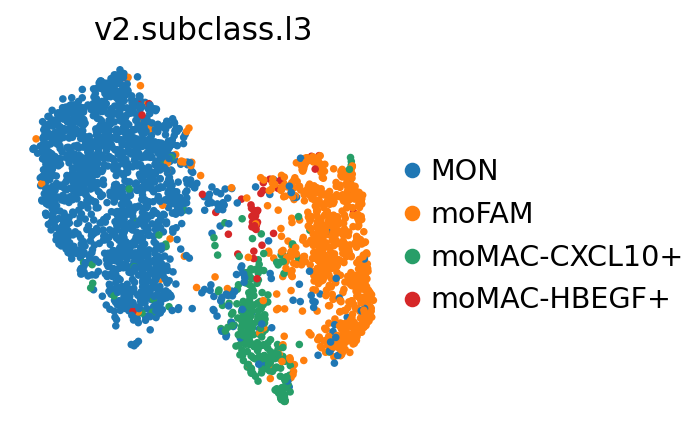

In [4]:
sc.pl.umap(adata, color=["v2.subclass.l3"], ncols=1)

In [5]:
root_celltype = "MON"

sc.pp.neighbors(adata, use_rep="X_pca", n_pcs=20)
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, use_rep="X_diffmap")
sc.tl.paga(adata, groups="v2.subclass.l3")
iroot = np.flatnonzero(adata.obs["v2.subclass.l3"] == root_celltype)[0]
adata.uns["iroot"] = iroot
sc.tl.dpt(adata)

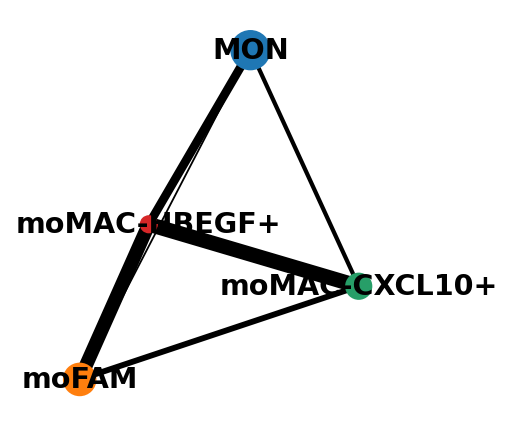

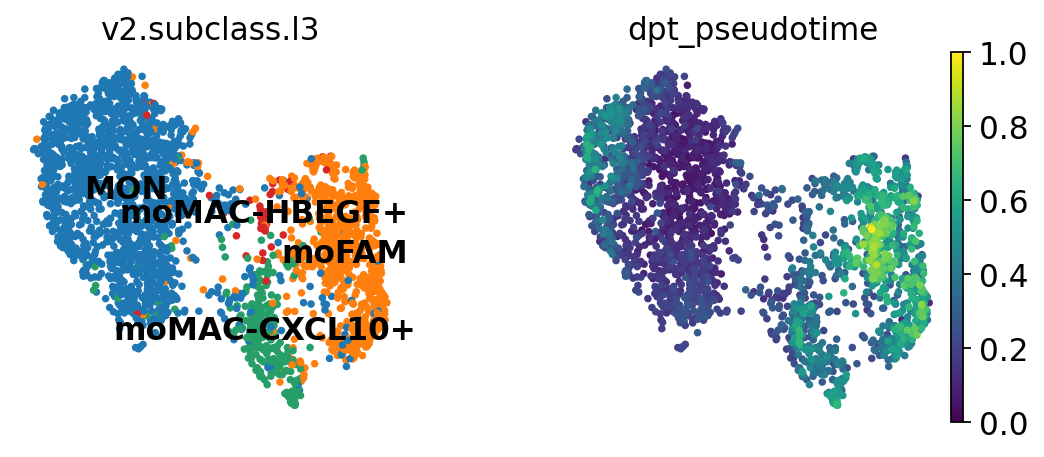

In [6]:
sc.pl.paga(adata, color=["v2.subclass.l3"],
save='PAGA_Myeloid_dpt_paga.png')
sc.pl.umap(adata, color=["v2.subclass.l3", "dpt_pseudotime"], legend_loc="on data",
save='PAGA_Myeloid_dpt_umap.png')